In [1]:
from sf_workingdir_lilly.dmlab.custom_esn_analysis import get_hidden_states_iso_feat
import torch
import numpy as np
import matplotlib.pyplot as plt


In [2]:
time_steps = 70
#[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
spectral_radius = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5, 6, 7, 8]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=4
fixed_whh=True
fixed_wih=False

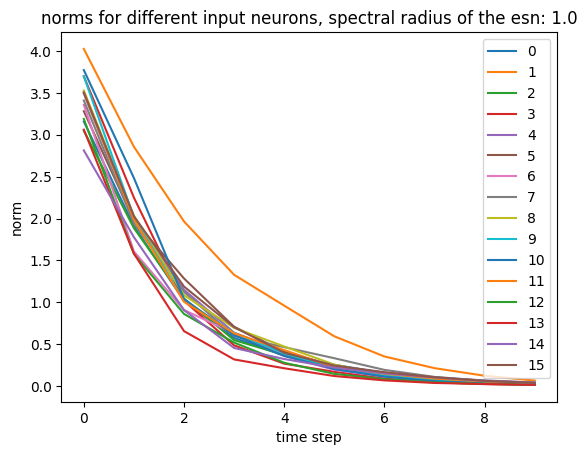

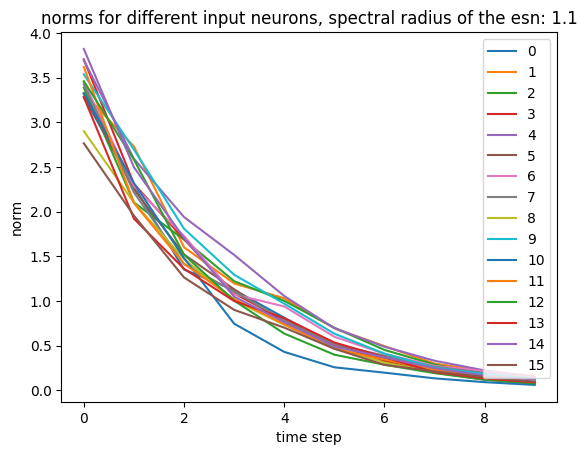

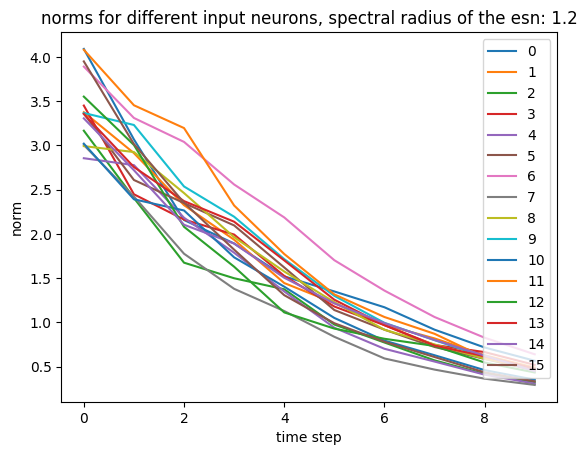

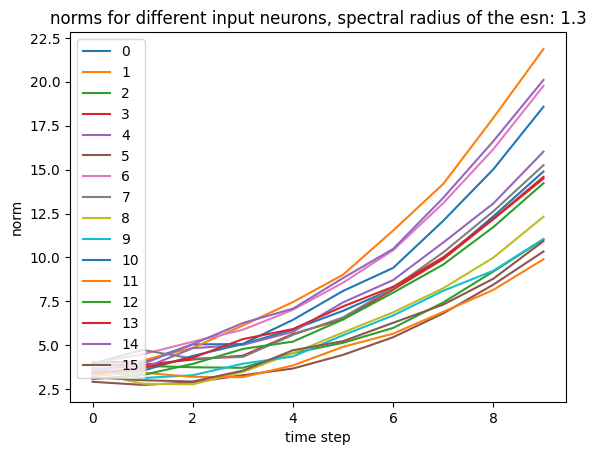

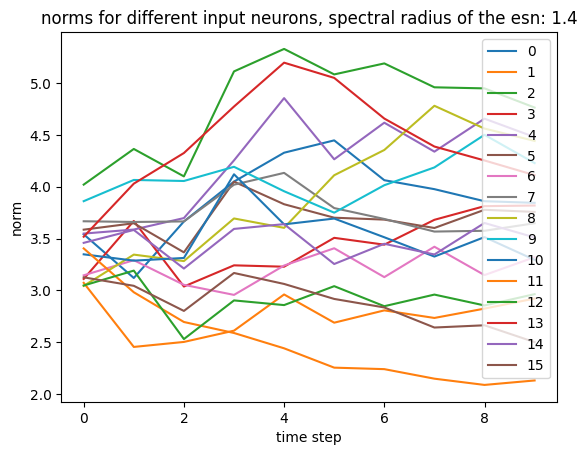

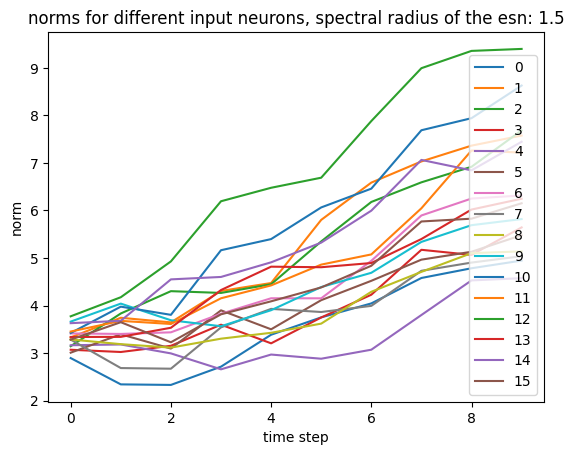

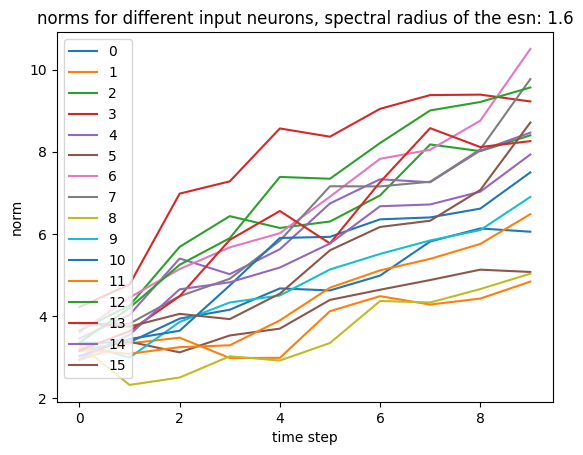

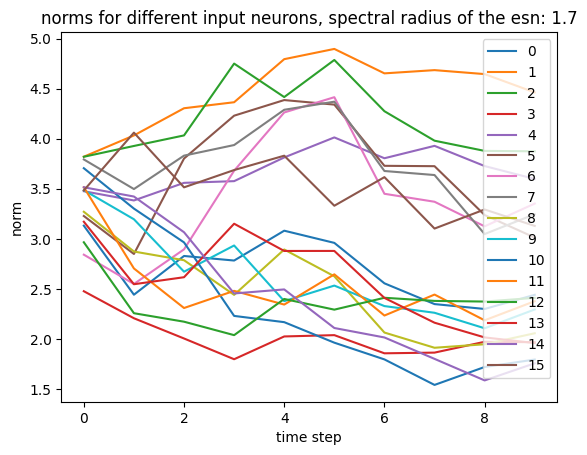

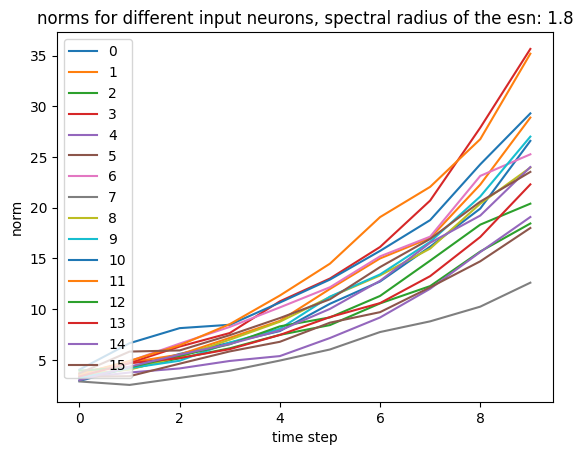

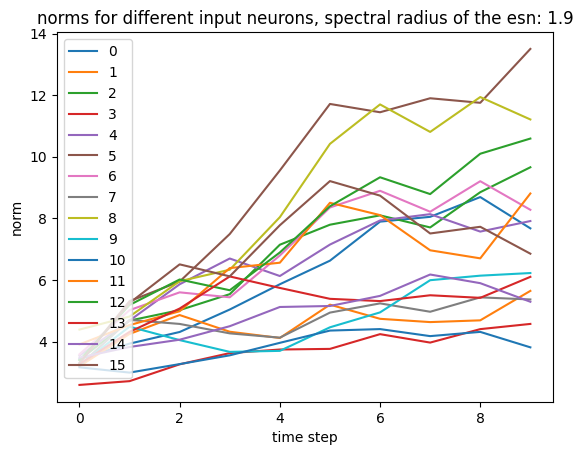

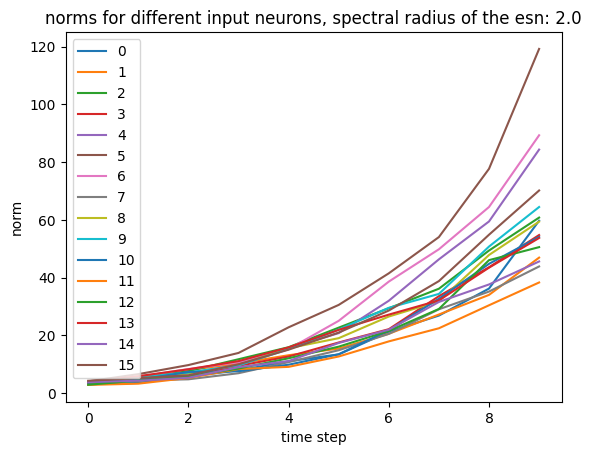

In [3]:
# plot the norms over different input neurons to see for how long the input information stays in the esn

neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))

for sr_i, sr in enumerate(spectral_radius):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    plt.figure()
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        norms = hs.norm(dim=1)
        #neuron_norms[i,:] = norms
        neuron_norms_for_srs[sr_i,i,:] = norms
        plt.plot(norms[:10], label=f'{i}')
    
    plt.title(f'norms for different input neurons, spectral radius of the esn: {sr}')
    plt.xlabel('time step')
    plt.ylabel('norm')
    plt.legend()
    

     

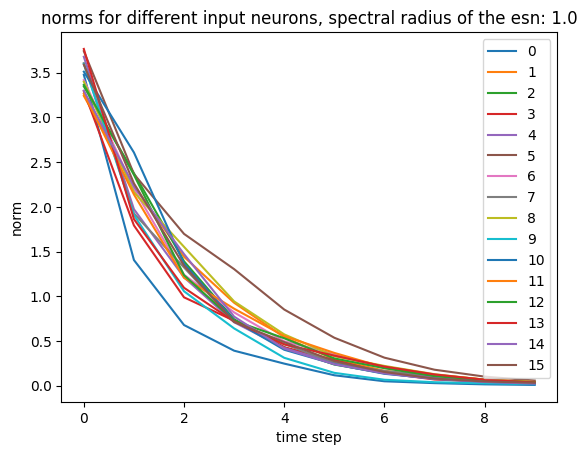

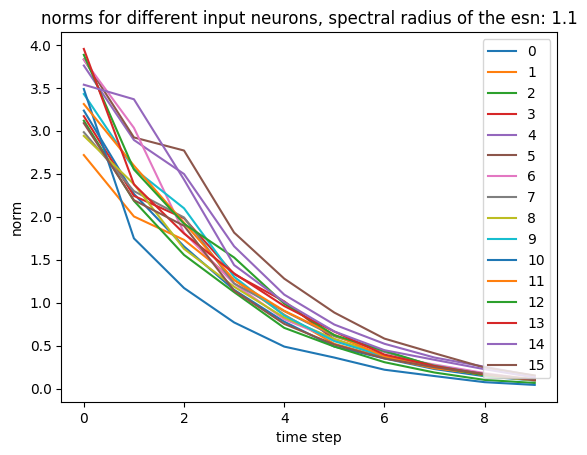

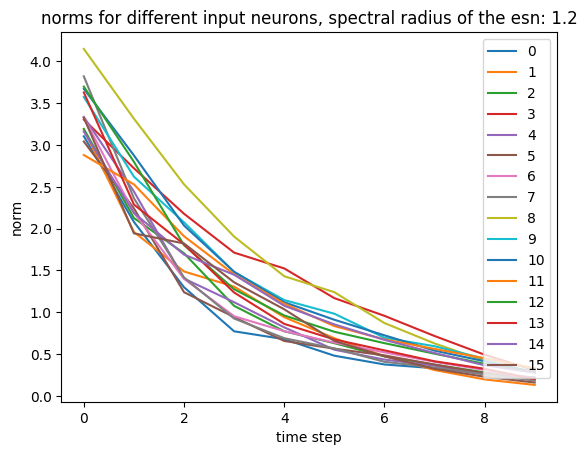

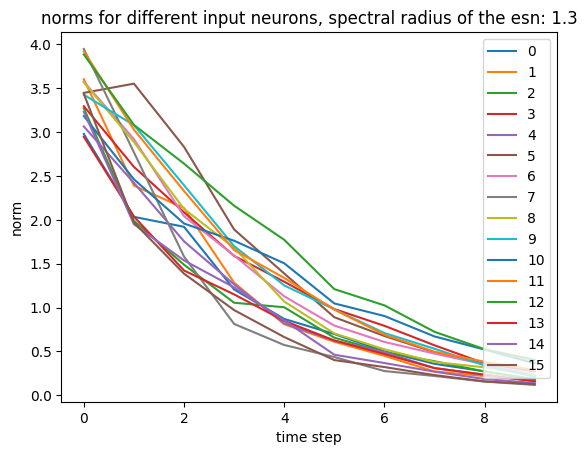

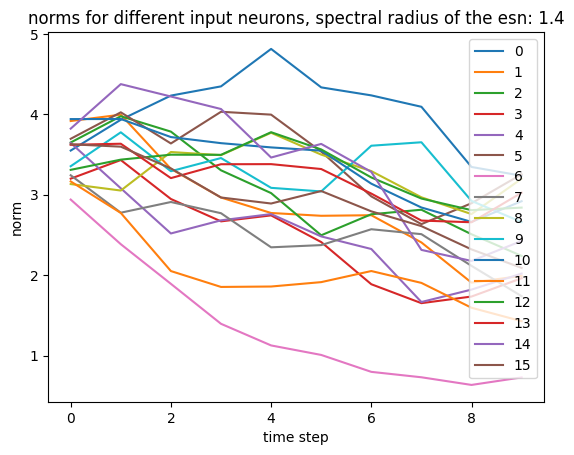

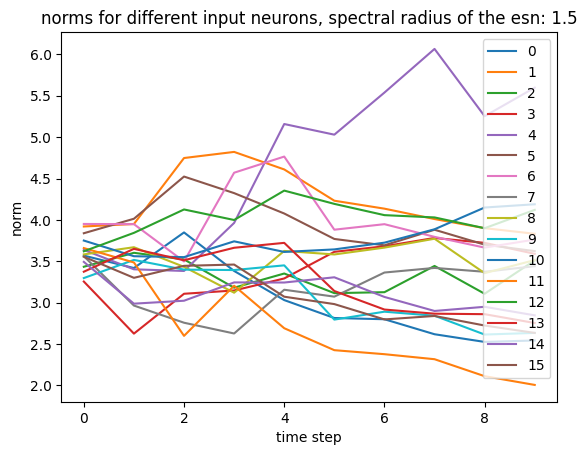

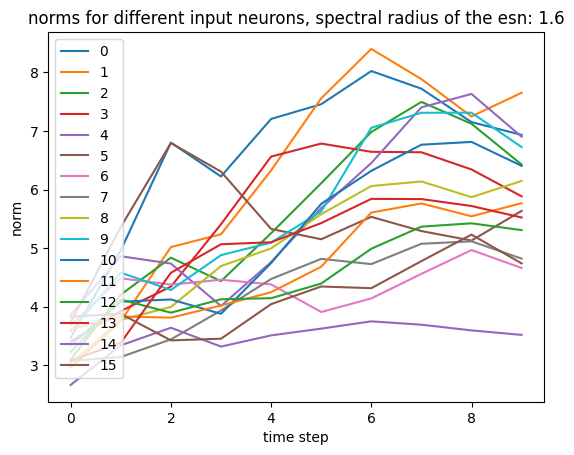

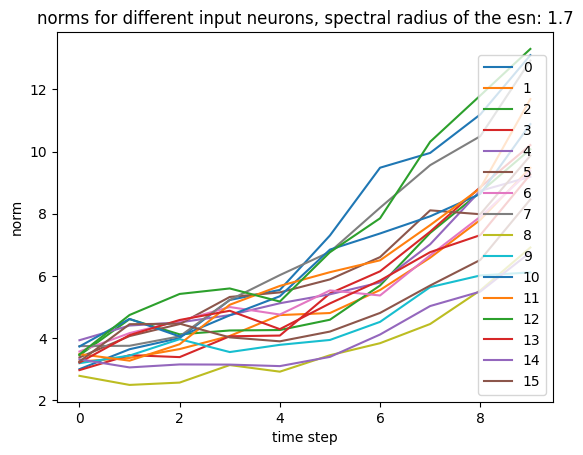

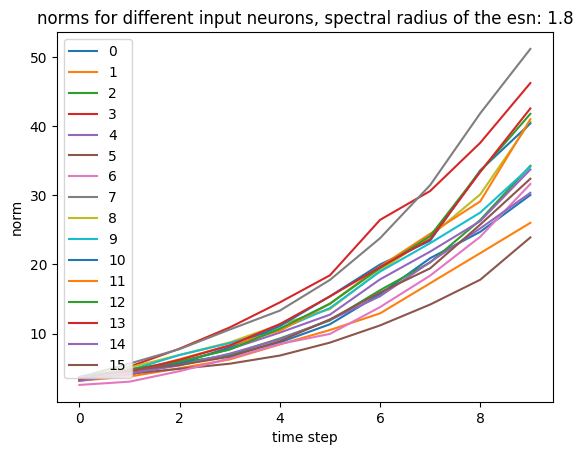

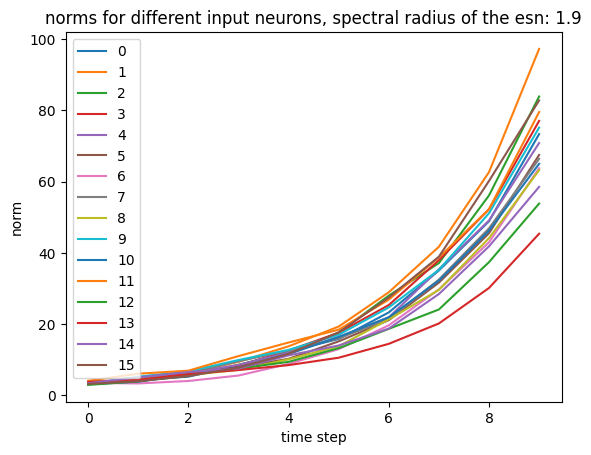

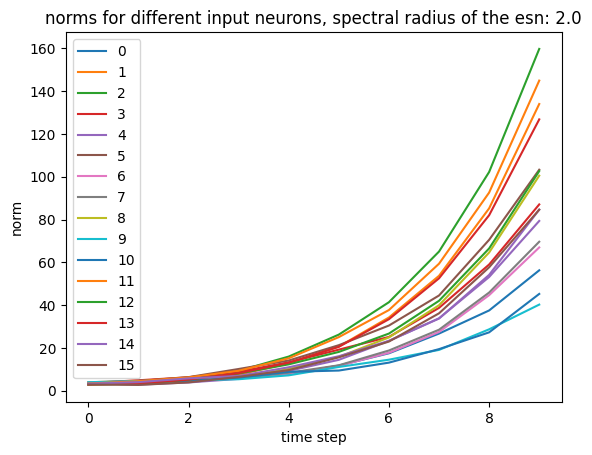

In [4]:
time_steps = 70
#[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
spectral_radius = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5, 6, 7, 8]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=5
fixed_whh=True
fixed_wih=False

# plot the norms over different input neurons to see for how long the input information stays in the esn

neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))

for sr_i, sr in enumerate(spectral_radius):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    plt.figure()
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        norms = hs.norm(dim=1)
        #neuron_norms[i,:] = norms
        neuron_norms_for_srs[sr_i,i,:] = norms
        plt.plot(norms[:10], label=f'{i}')
    
    plt.title(f'norms for different input neurons, spectral radius of the esn: {sr}')
    plt.xlabel('time step')
    plt.ylabel('norm')
    plt.legend()

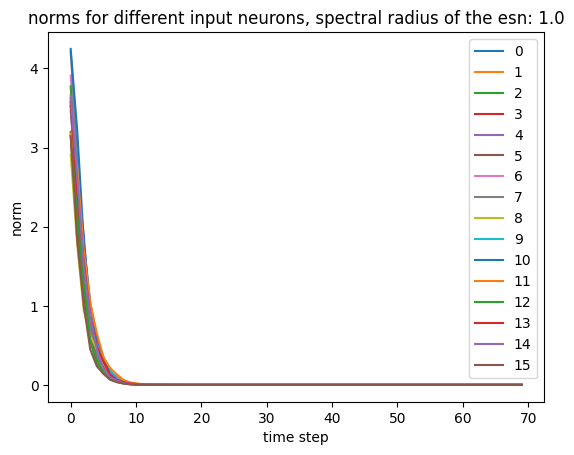

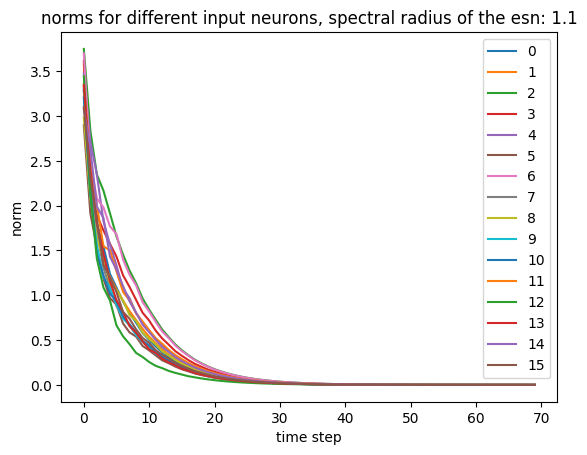

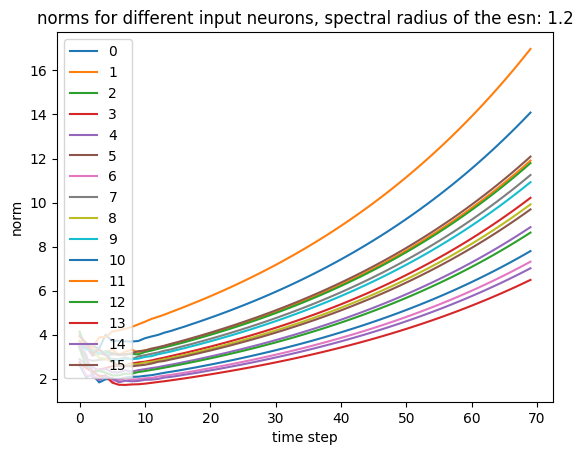

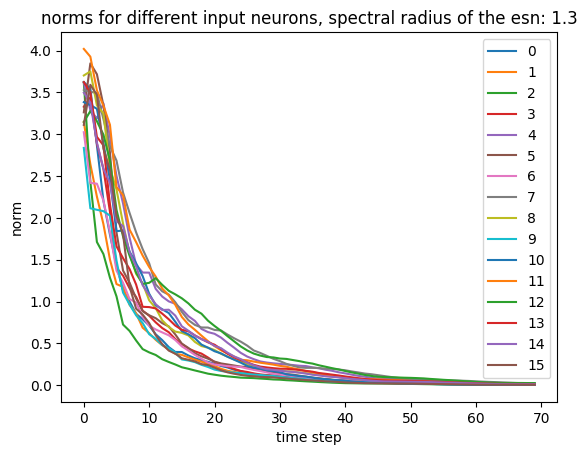

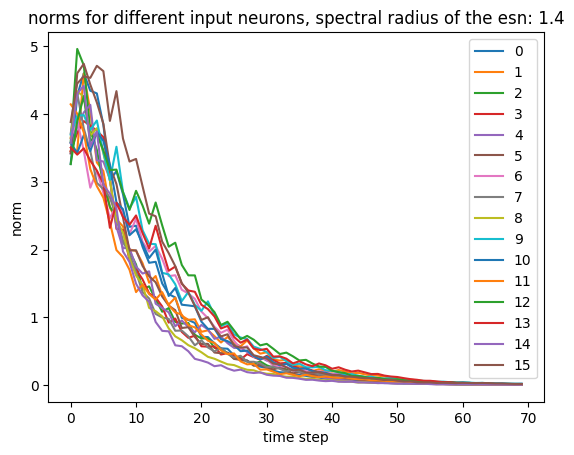

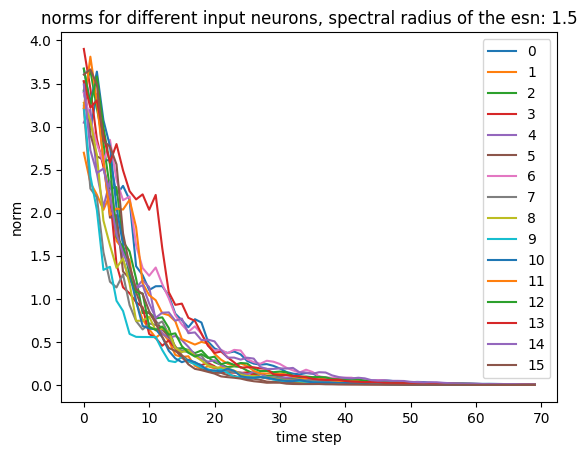

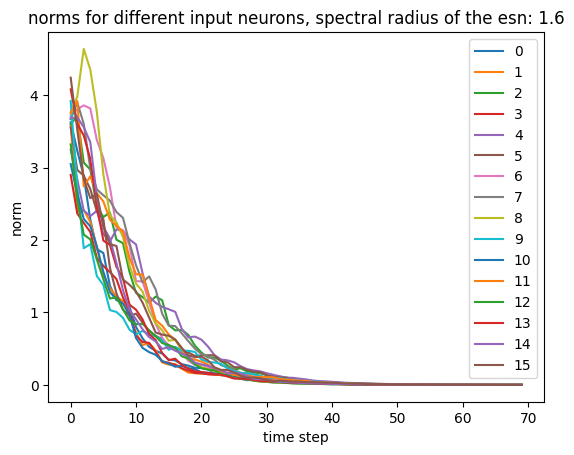

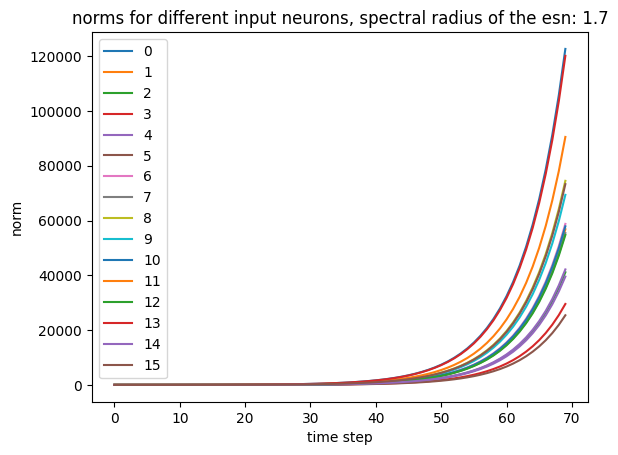

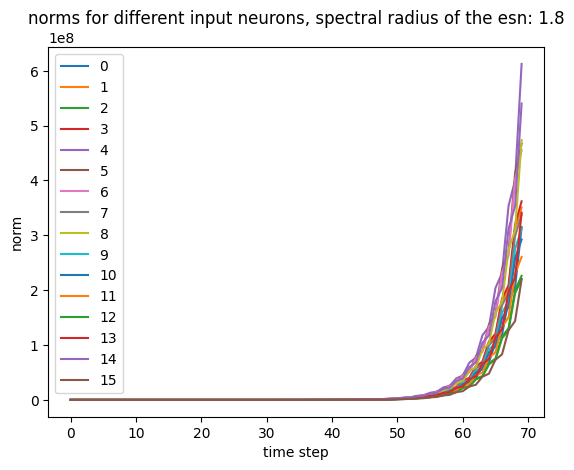

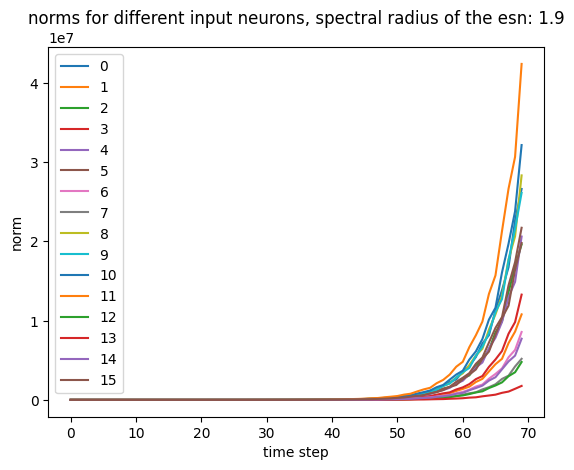

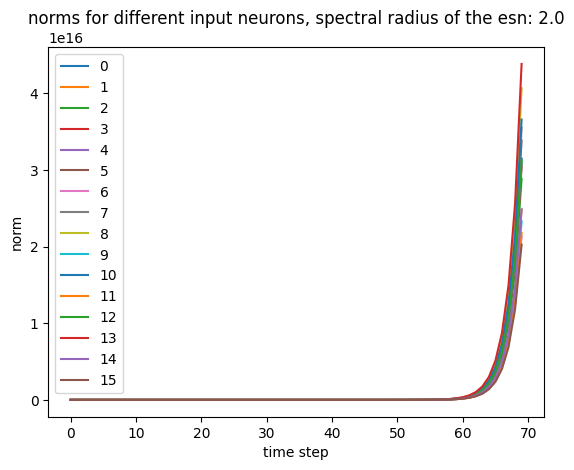

In [5]:
time_steps = 70
#[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
spectral_radius = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5, 6, 7, 8]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=6
fixed_whh=True
fixed_wih=False

# plot the norms over different input neurons to see for how long the input information stays in the esn

neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))

for sr_i, sr in enumerate(spectral_radius):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    plt.figure()
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        norms = hs.norm(dim=1)
        #neuron_norms[i,:] = norms
        neuron_norms_for_srs[sr_i,i,:] = norms
        plt.plot(norms, label=f'{i}')
    
    plt.title(f'norms for different input neurons, spectral radius of the esn: {sr}')
    plt.xlabel('time step')
    plt.ylabel('norm')
    plt.legend()

In [6]:
# define a threshold and see at which time step the norms cross the threshold
# with this you can see at which time step there is basically no more information of the original input in the system

threshold = 0.05

threshold_was_reached = np.zeros((len(spectral_radius), Hippo_n_feature))
print(threshold_was_reached.shape)

for sr_i, sr in enumerate(spectral_radius):
    for i in range(Hippo_n_feature):
        current_norms = neuron_norms_for_srs[sr_i,i,:]
        threshold_idx = np.where(current_norms <= threshold)
        print(threshold_idx)
        print(sr)
        if not threshold_idx[0].any():
            break
        threshold_was_reached[sr_i,i] = threshold_idx[0][0]
    

(11, 16)
(array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
       25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41,
       42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58,
       59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]),)
1.0
(array([ 7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
       24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
       41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57,
       58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]),)
1.0
(array([ 7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
       24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40,
       41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57,
       58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69]),)
1.0
(array([ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
       25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 

In [7]:
# at what time step was the threshold reached for each spectral radius - for each different feature that received a non zero input in the beginning

print(threshold_was_reached)
print(threshold_was_reached.mean(axis=1))

[[ 8.  7.  7.  8.  8.  8.  9.  8.  8.  8.  8.  9.  7.  8.  8.  7.]
 [25. 26. 28. 27. 26. 23. 28. 24. 26. 24. 24. 27. 21. 24. 26. 25.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [41. 41. 34. 41. 57. 40. 44. 60. 46. 37. 41. 51. 59. 52. 45. 37.]
 [45. 56. 52. 50. 44. 48. 53. 53. 44. 56. 54. 51. 56. 57. 42. 53.]
 [47. 33. 37. 33. 36. 28. 44. 36. 31. 30. 31. 39. 43. 40. 45. 26.]
 [30. 34. 38. 30. 39. 36. 36. 34. 29. 36. 32. 37. 29. 30. 32. 34.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
[ 7.875  25.25    0.     45.375  50.875  36.1875 33.5     0.      0.
  0.      0.    ]


In [8]:
threshold = 0.0001

threshold_was_reached = np.zeros((len(spectral_radius), Hippo_n_feature))

for sr_i, sr in enumerate(spectral_radius):
    for i in range(Hippo_n_feature):
        current_norms = neuron_norms_for_srs[sr_i,i,:]
        threshold_idx = np.where(current_norms <= threshold)
        if not threshold_idx[0].any():
            break
        threshold_was_reached[sr_i,i] = threshold_idx[0][0]

print(threshold_was_reached)
print(threshold_was_reached.mean(axis=1))

[[18. 17. 16. 17. 17. 17. 17. 17. 17. 17. 18. 18. 16. 17. 17. 15.]
 [65. 65. 68. 67. 66. 63. 68. 64. 65. 64. 64. 66. 61. 63. 66. 64.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]]
[16.9375 64.9375  0.      0.      0.      0.      0.      0.      0.
  0.      0.    ]


In [9]:
# now look at the angles between the state vectors
'''
time_steps = 70
#[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
spectral_radius = [1.6] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5, 6, 7, 8]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=6
fixed_whh=True
fixed_wih=False

from sf_workingdir_lilly.dmlab.custom_esn_analysis import compute_angle_between_hidden_states, compute_angle_plane_hidden_state


#neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))
x_vals = np.arange(1,70)
x_vals_plane = np.arange(2,70)

for sr_i, sr in enumerate(spectral_radius):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    for i in range(Hippo_n_feature):
        plt.figure()
        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        angles = compute_angle_between_hidden_states(hs, time_steps)
        angles_plane = compute_angle_plane_hidden_state(hs, time_steps)
        
        #neuron_norms[i,:] = norms
        #neuron_norms_for_srs[sr_i,i,:] = norms
        
        plt.scatter(x_vals, angles, label=f'vector angle', s=5)
        plt.scatter(x_vals_plane, angles_plane, label=f'plane-vector angle', s=5)
    
        plt.title(f'angles between hidden states for different input neurons, feature: {i}')
        plt.xlabel('time step')
        plt.ylabel('angle [rad]')
        plt.legend()
 '''   

"\ntime_steps = 70\n#[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]\nspectral_radius = [1.6] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5, 6, 7, 8]\nHippo_n_feature = 16\nHippo_R = 8\nHippo_L = 64\ntrial=6\nfixed_whh=True\nfixed_wih=False\n\nfrom sf_workingdir_lilly.dmlab.custom_esn_analysis import compute_angle_between_hidden_states, compute_angle_plane_hidden_state\n\n\n#neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))\nx_vals = np.arange(1,70)\nx_vals_plane = np.arange(2,70)\n\nfor sr_i, sr in enumerate(spectral_radius):\n    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time\n    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))\n    for i in range(Hippo_n_feature):\n        plt.figure()\n        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hip

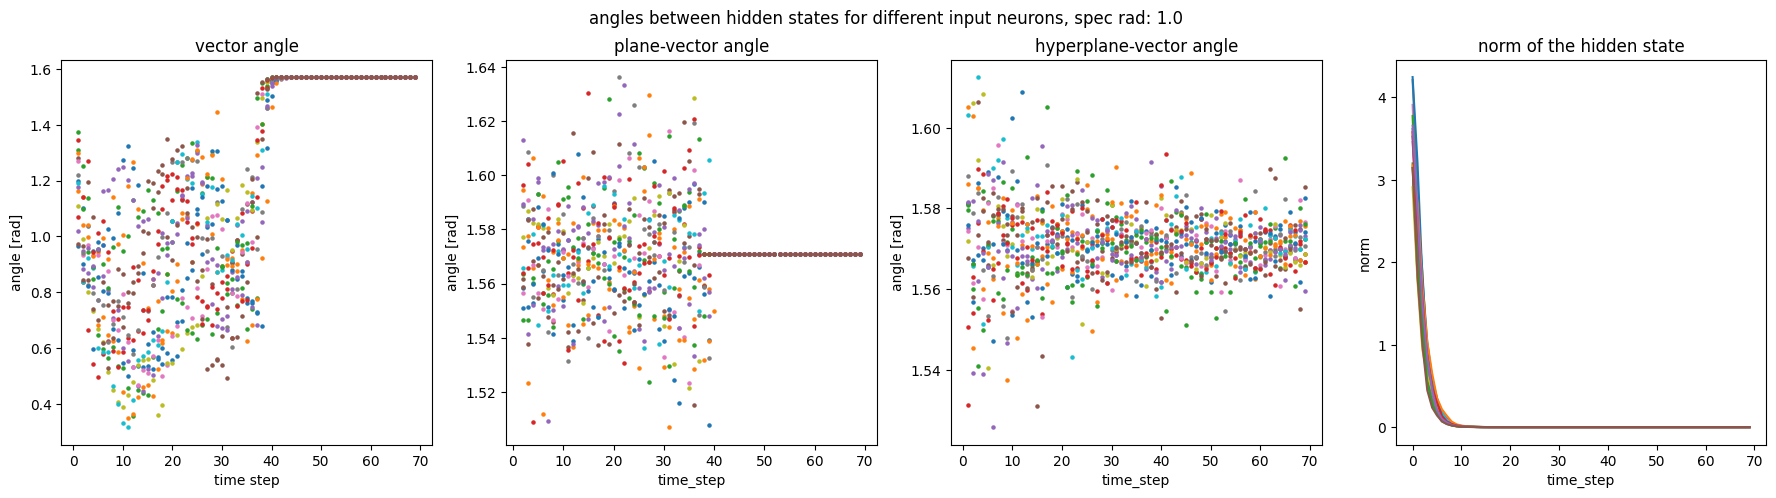

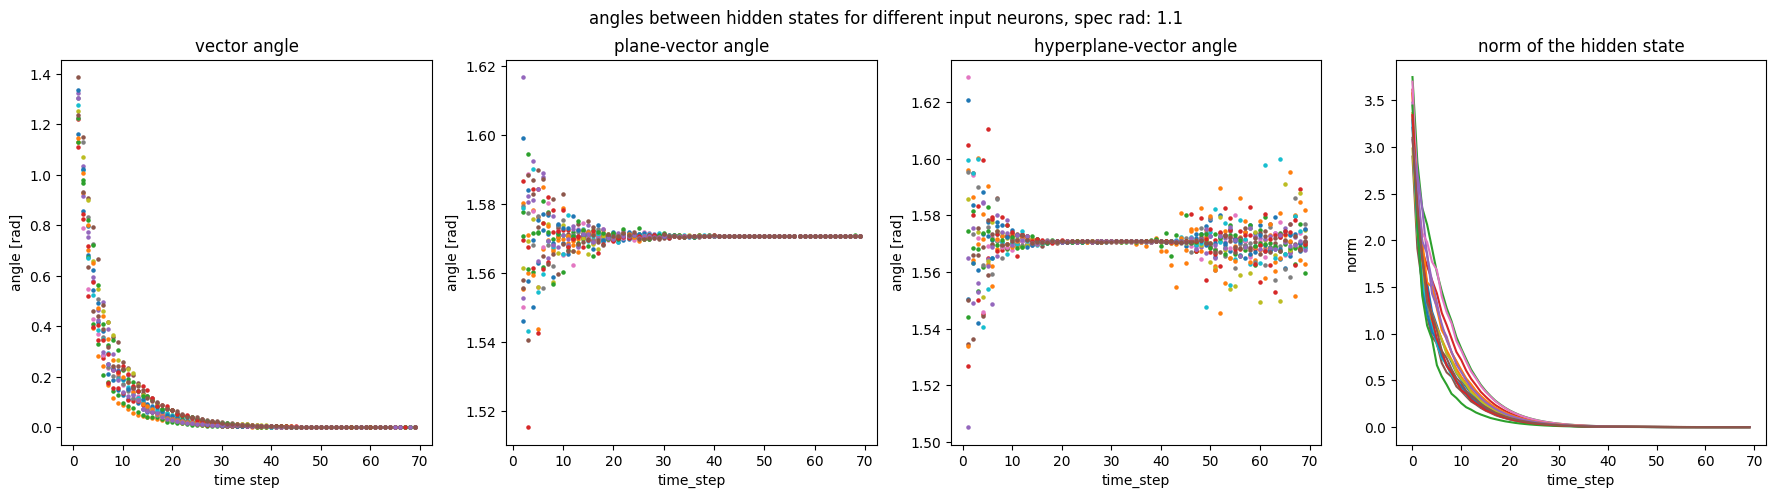

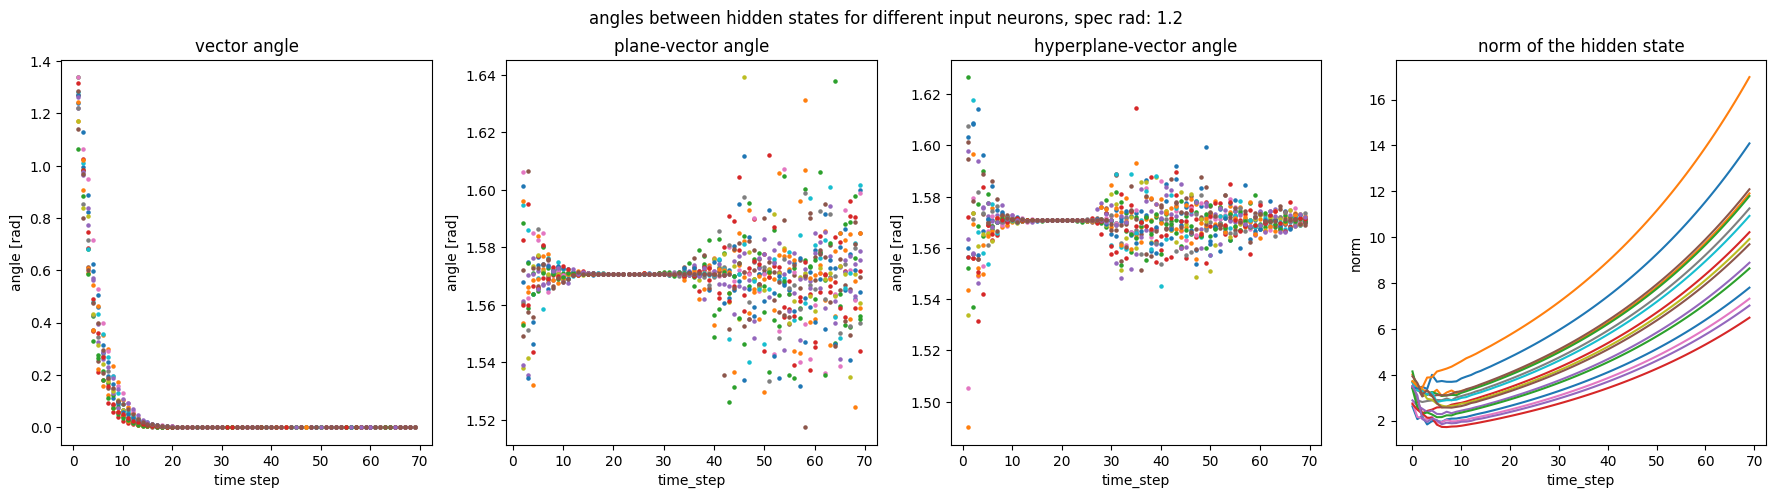

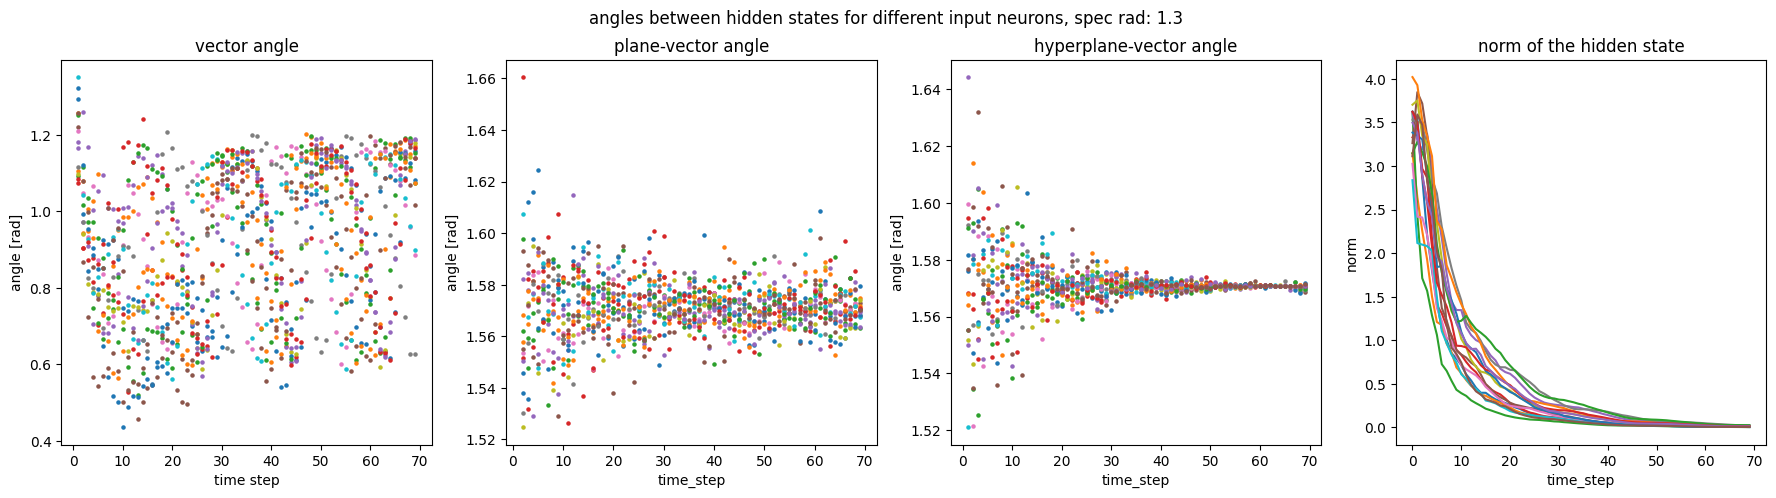

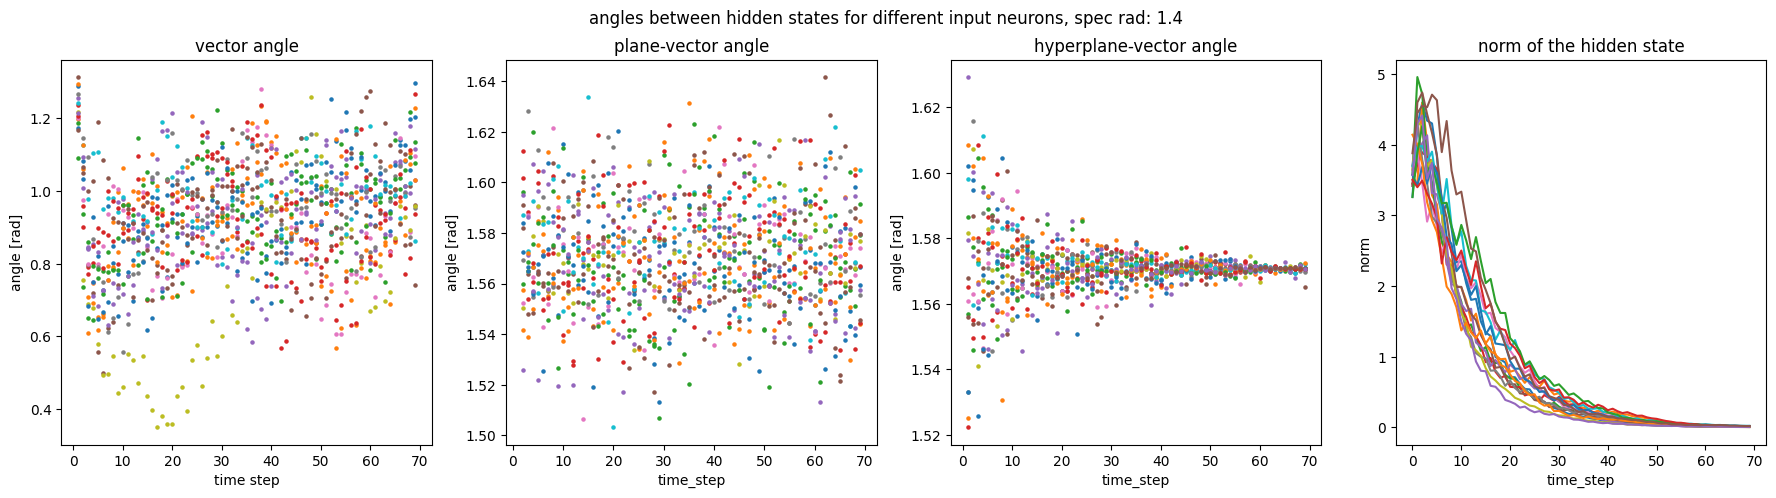

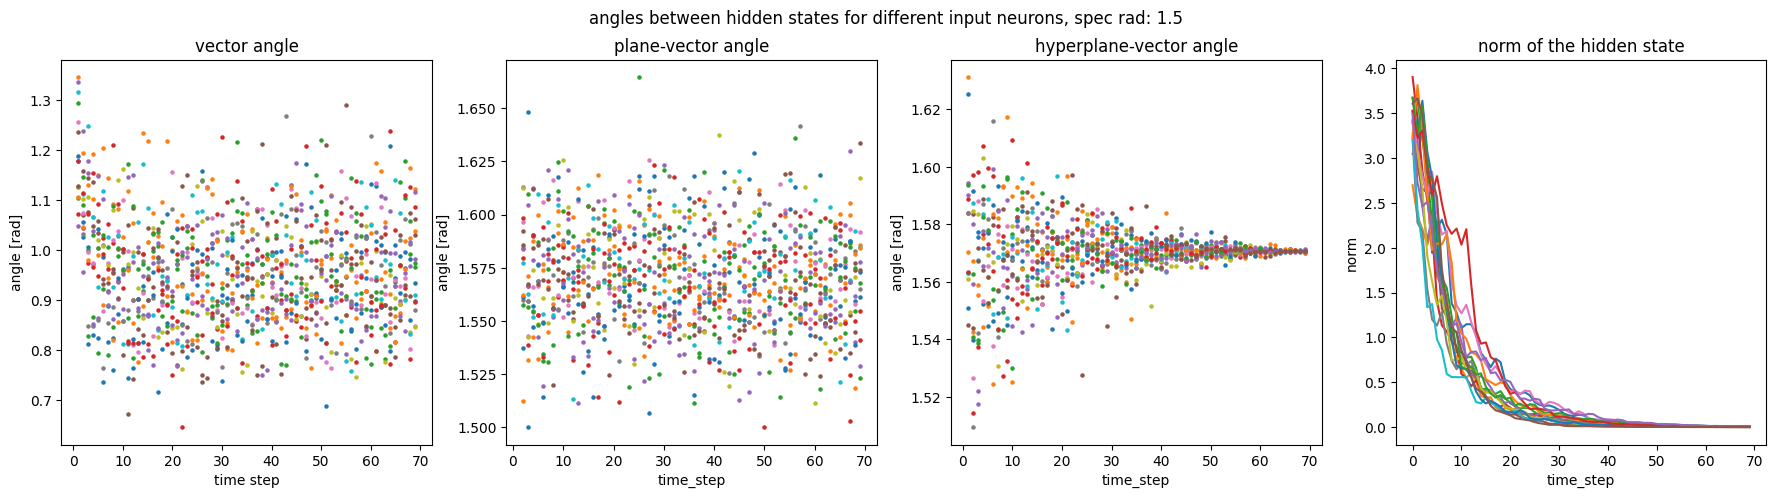

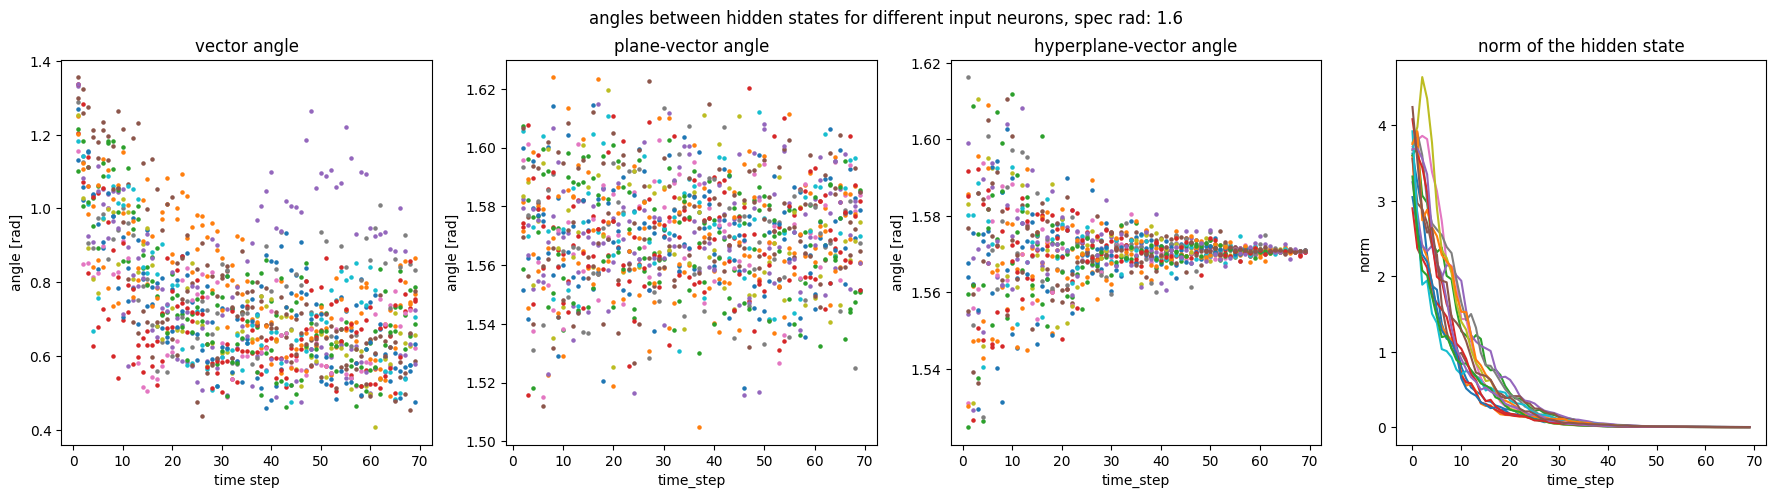

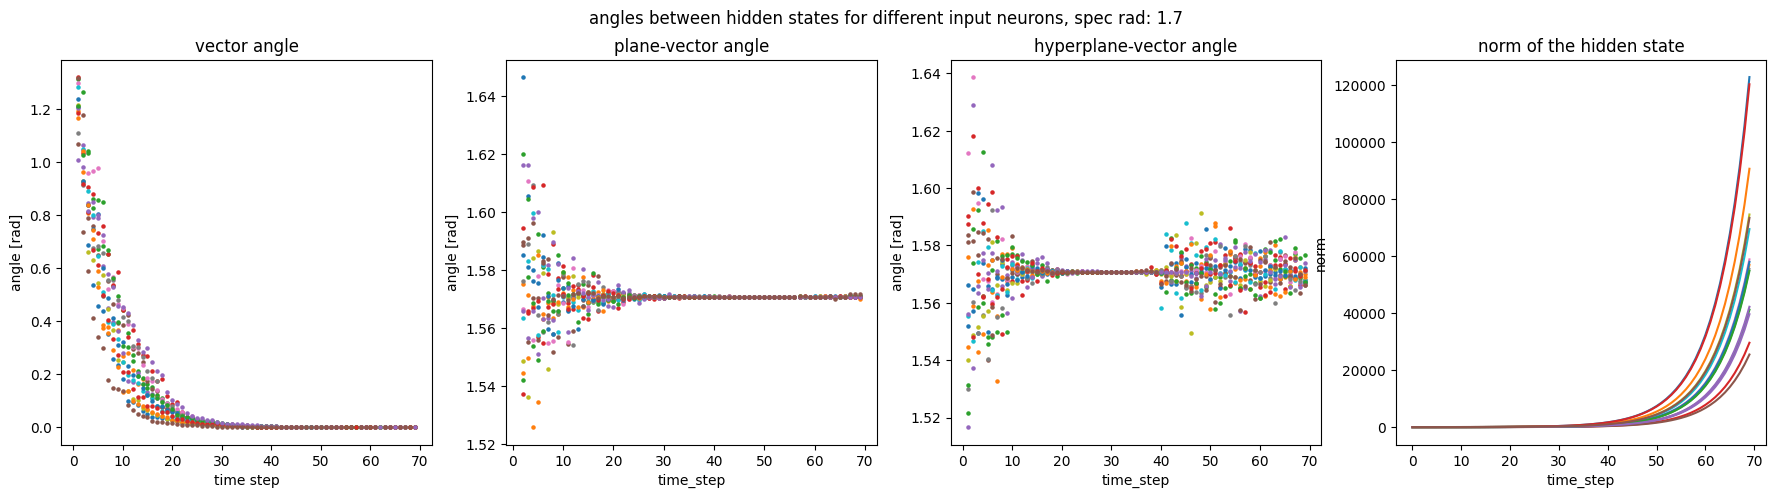

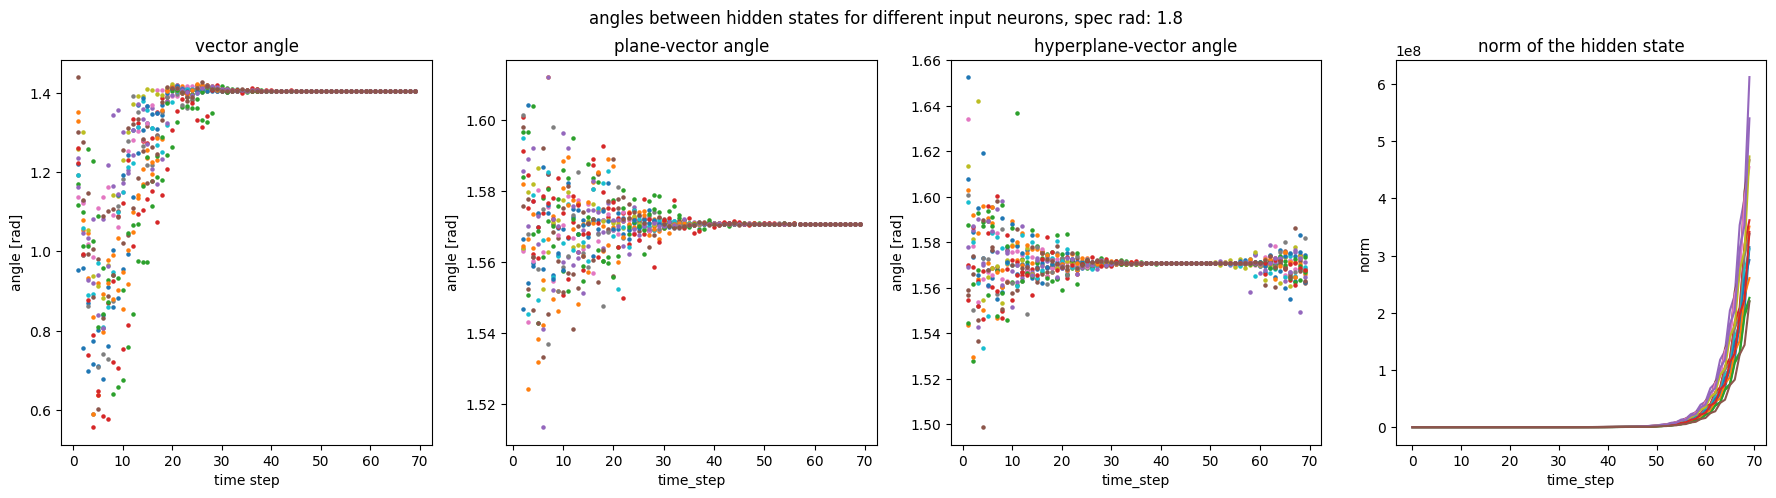

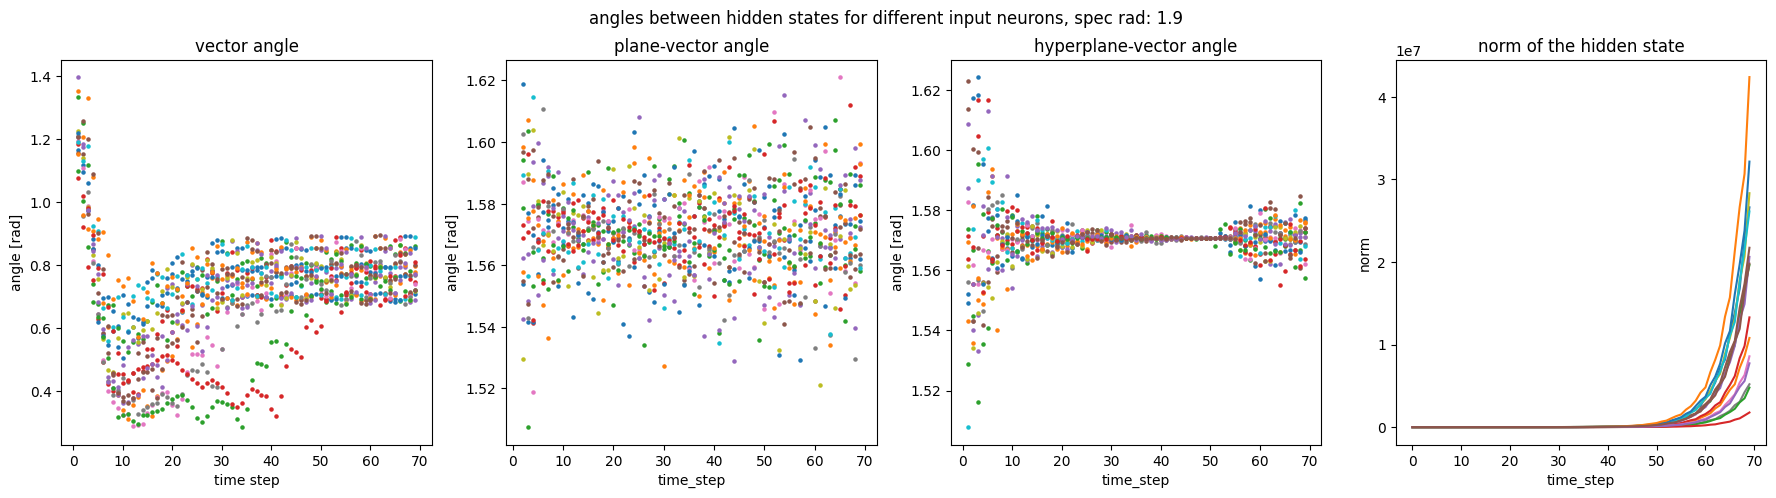

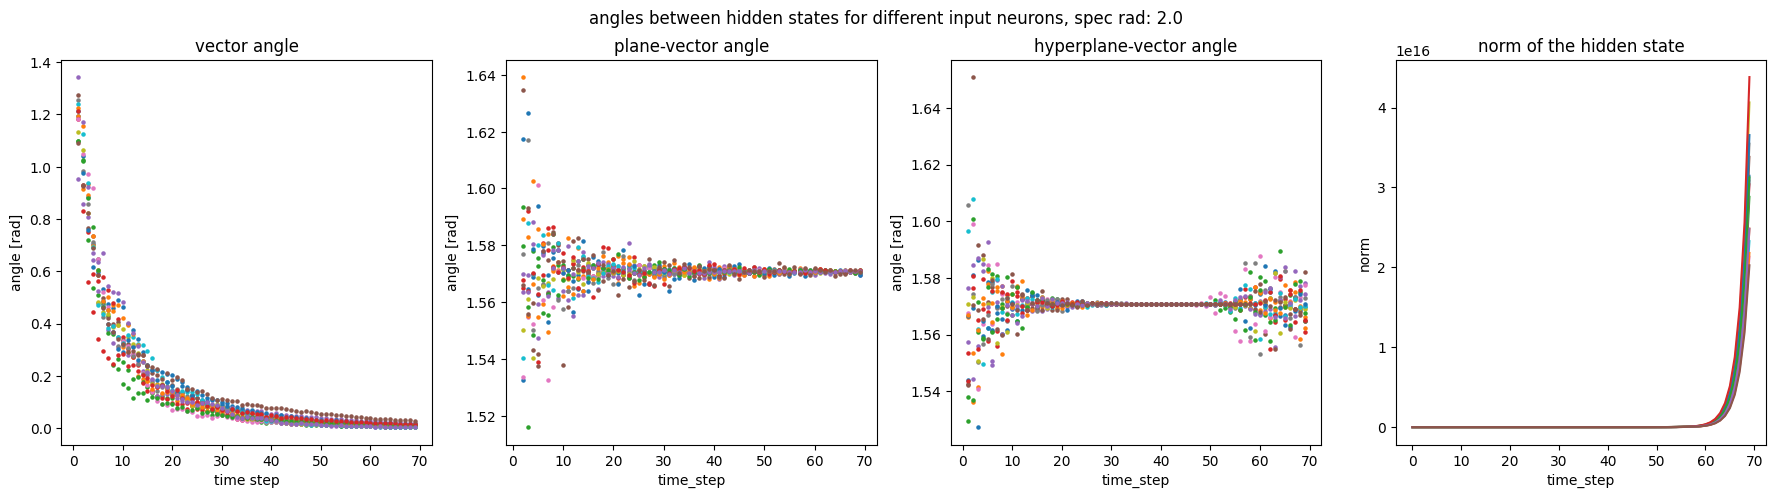

In [10]:
# now just the plot of the vector angles for
time_steps = 70
#[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
spectral_radius = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5, 6, 7, 8]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=6
fixed_whh=True
fixed_wih=False

from sf_workingdir_lilly.dmlab.custom_esn_analysis import compute_angle_between_hidden_states, compute_angle_hypperplane_hidden_state, compute_angle_plane_hidden_state


#neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))
x_vals = np.arange(1,70)
x_vals_plane = np.arange(2,70)

for sr_i, sr in enumerate(spectral_radius):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1,4, figsize=(22,5))
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        angles = compute_angle_between_hidden_states(hs, time_steps)
        angles_plane = compute_angle_plane_hidden_state(hs, time_steps)
        angles_hyperplane = compute_angle_hypperplane_hidden_state(hs, time_steps)

        norms = hs.norm(dim=1)
        
        #neuron_norms[i,:] = norms
        #neuron_norms_for_srs[sr_i,i,:] = norms
        
        ax1.scatter(x_vals, angles, label=f'{i}', s=5)
        ax2.scatter(x_vals_plane, angles_plane, label=f'{i}', s=5)
        ax3.scatter(x_vals, angles_hyperplane, label=f'{i}', s=5)
        ax4.plot(norms, label=f'{i}')
    
        fig.suptitle(f'angles between hidden states for different input neurons, spec rad: {sr}')
        ax1.set_title('vector angle')
        ax2.set_title('plane-vector angle')
        ax3.set_title('hyperplane-vector angle')
        ax4.set_title('norm of the hidden state')

        ax1.set_xlabel('time step')
        ax2.set_xlabel('time_step')
        ax3.set_xlabel('time_step')
        ax4.set_xlabel('time_step')

        ax1.set_ylabel('angle [rad]')
        ax2.set_ylabel('angle [rad]')
        ax3.set_ylabel('angle [rad]')
        ax4.set_ylabel('norm')
        #ax1.legend()
        #ax2.legend()

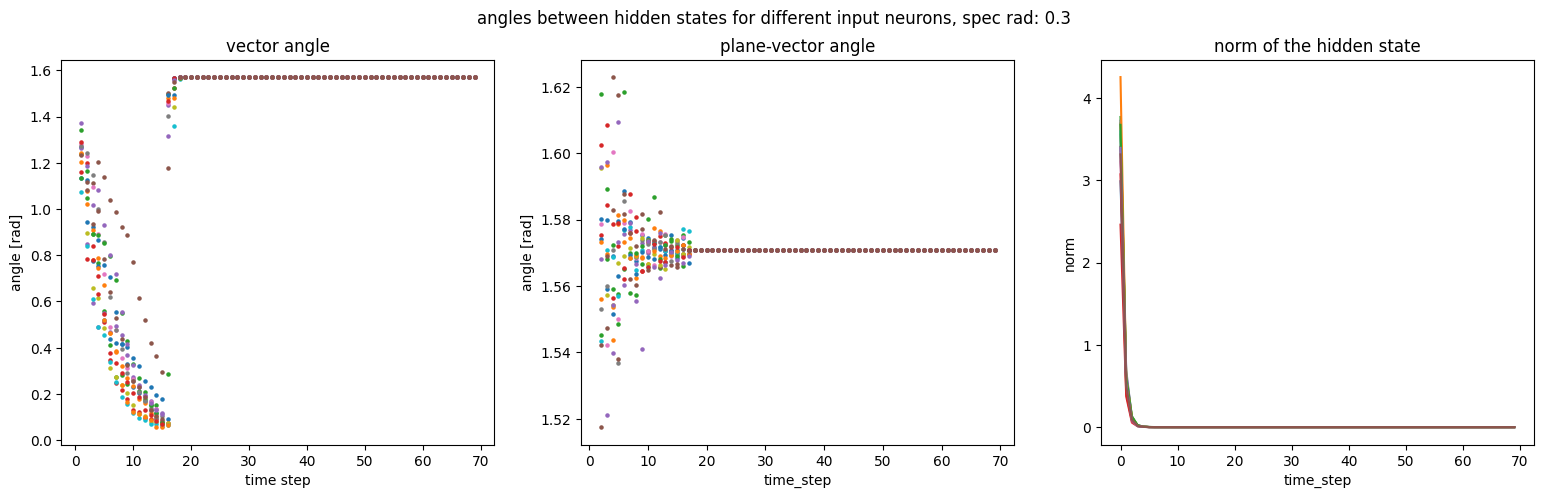

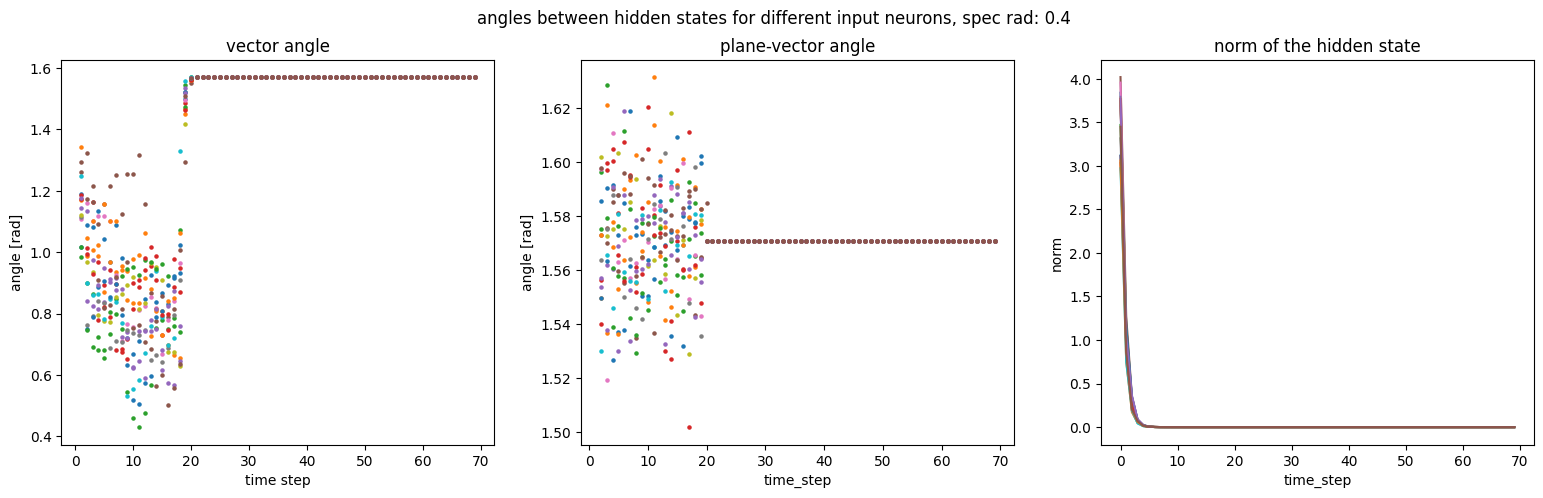

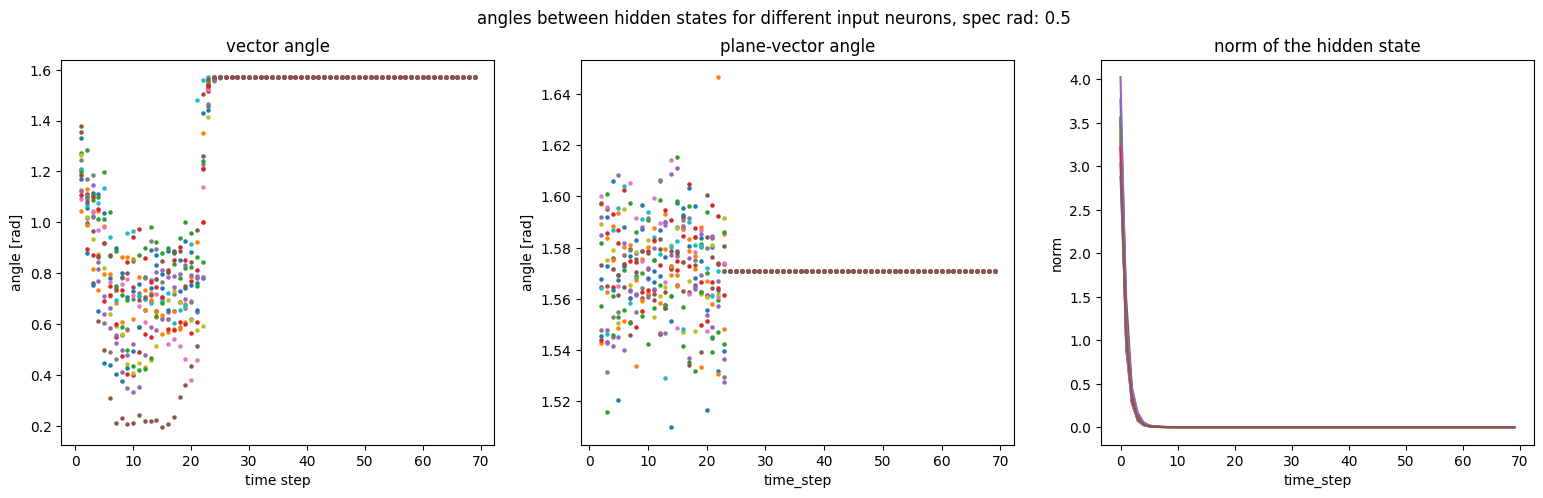

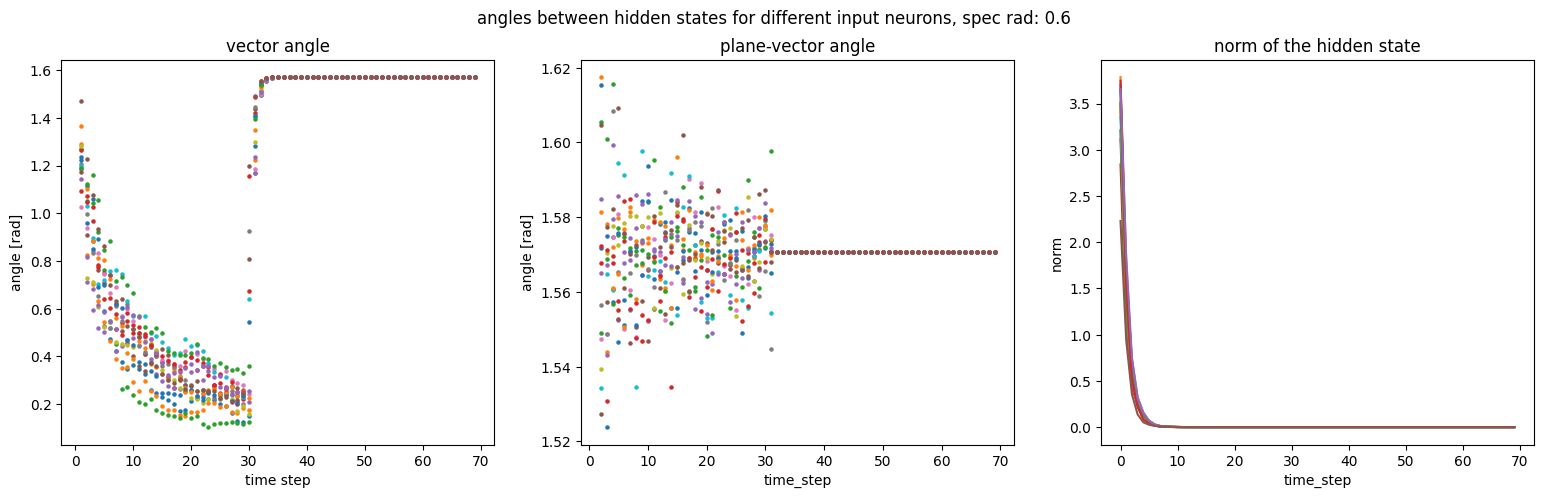

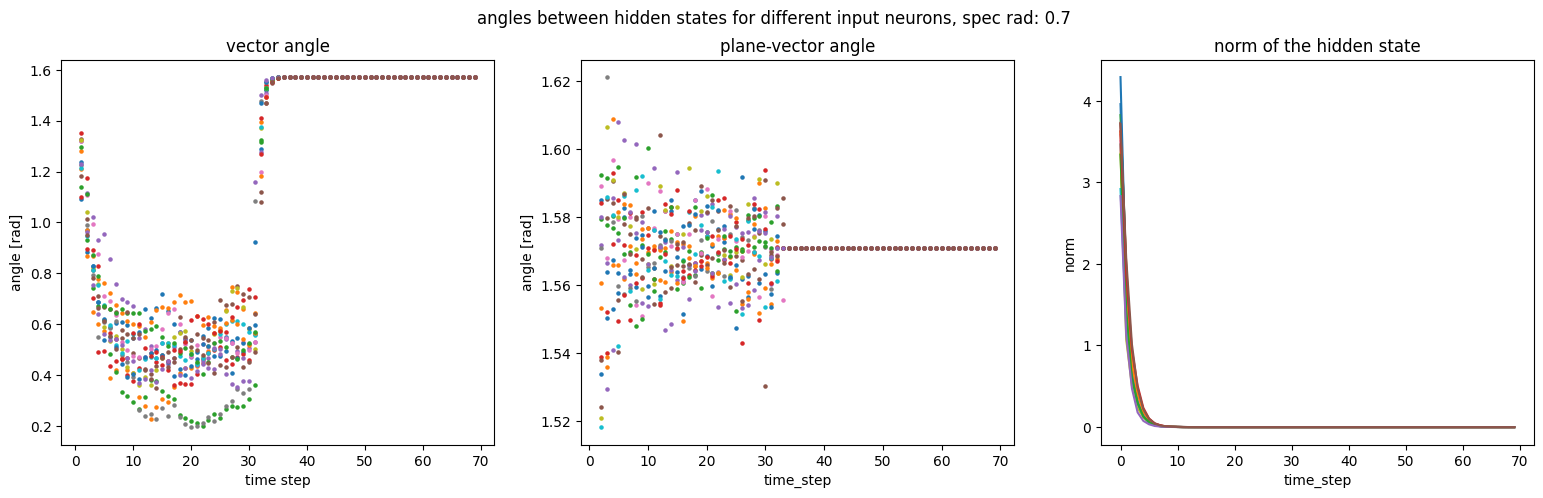

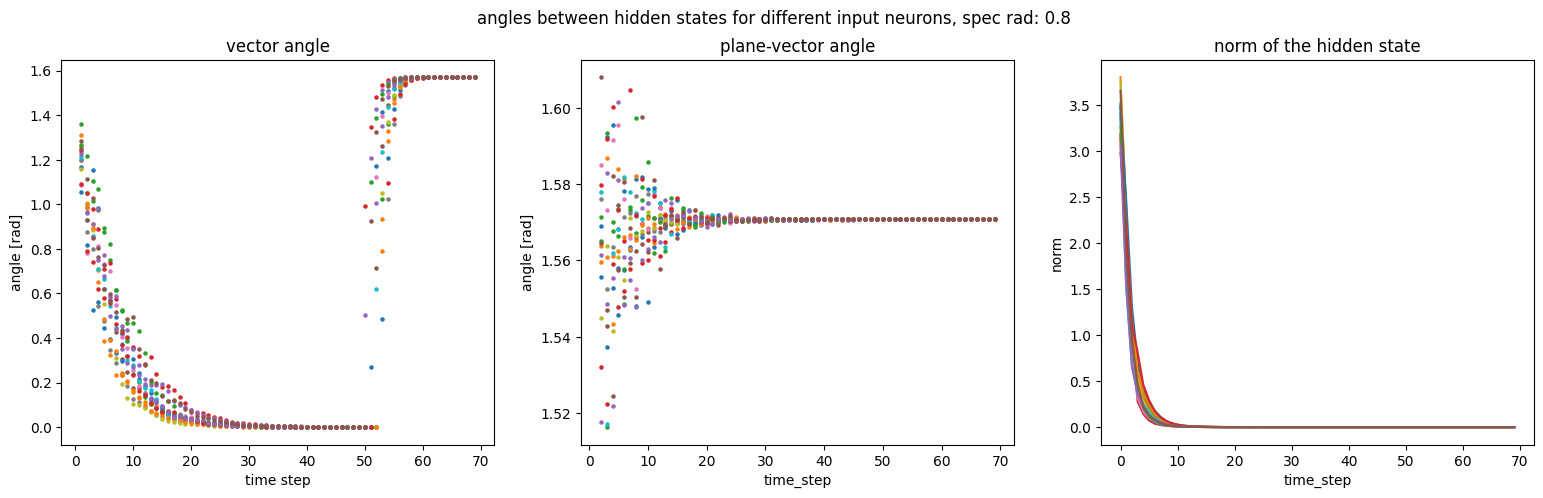

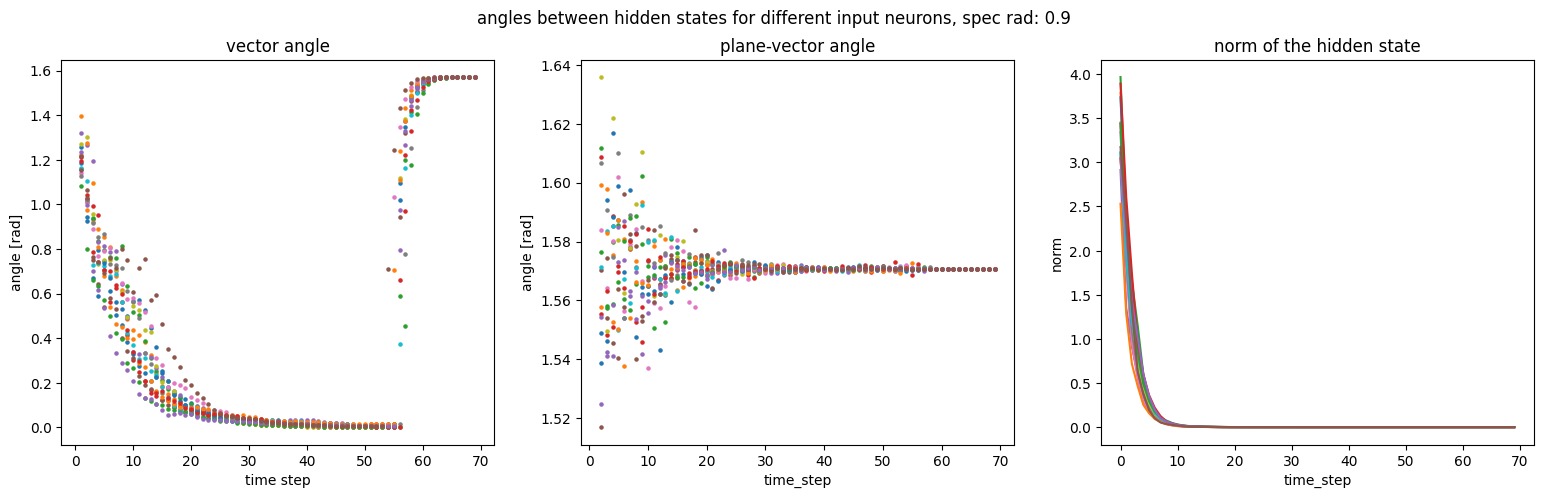

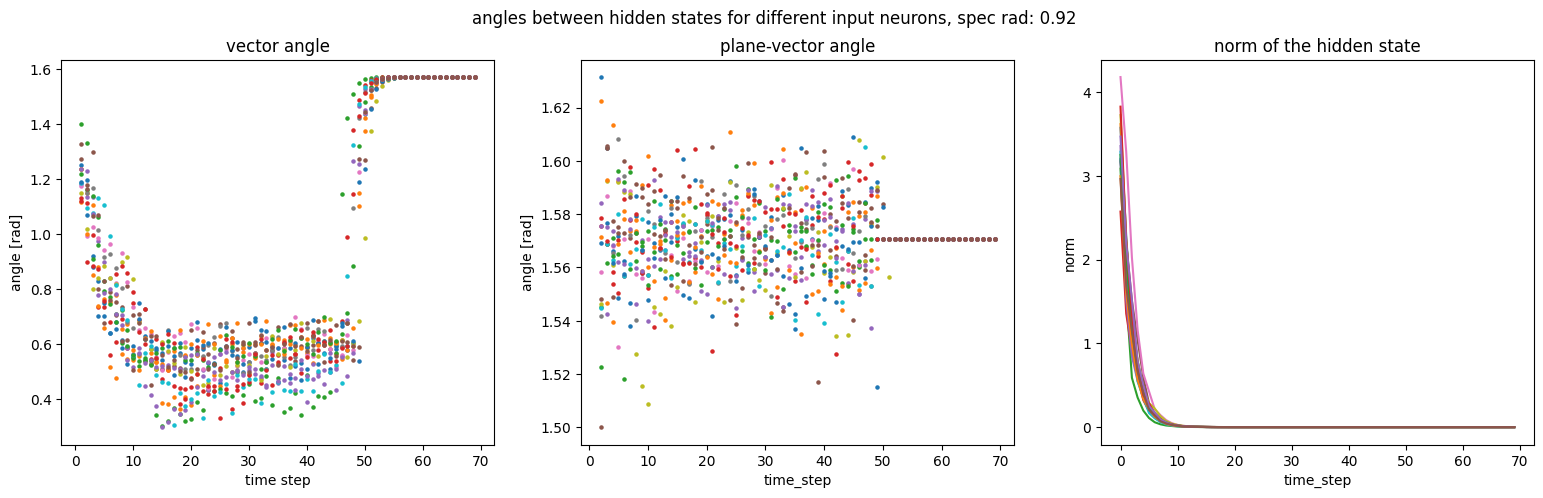

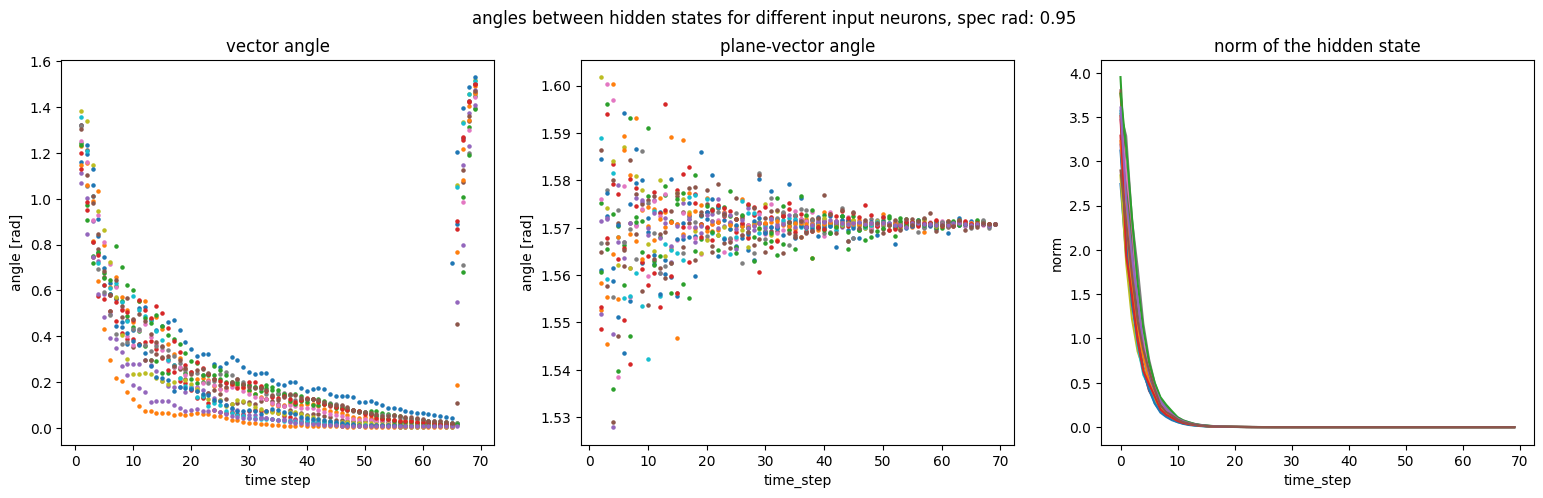

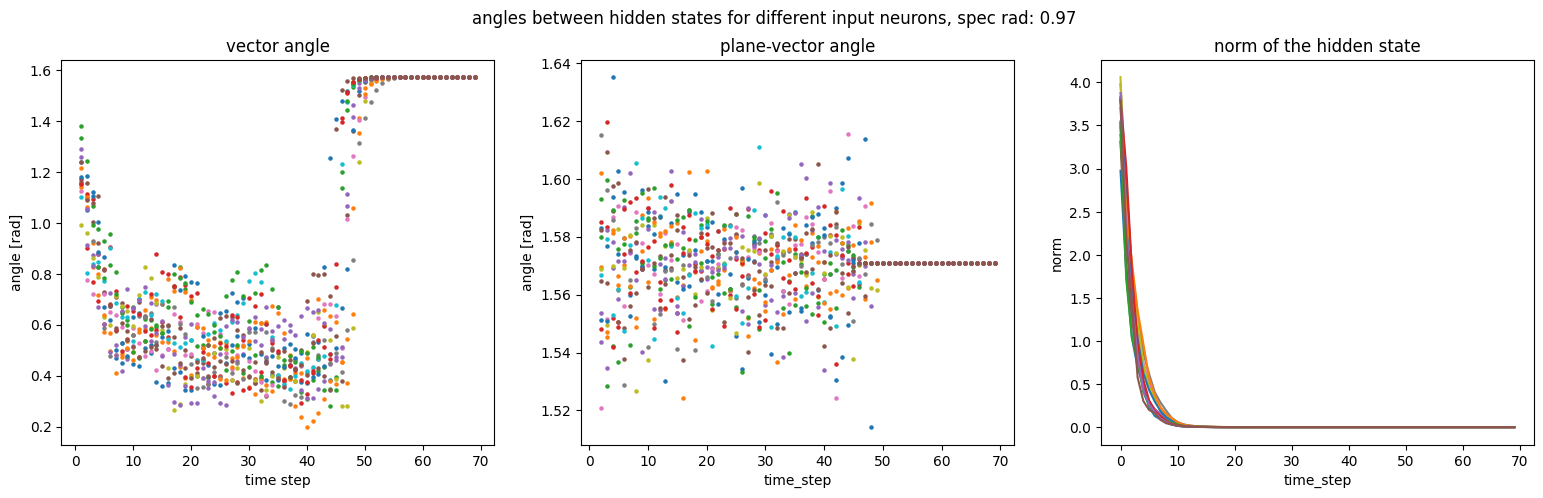

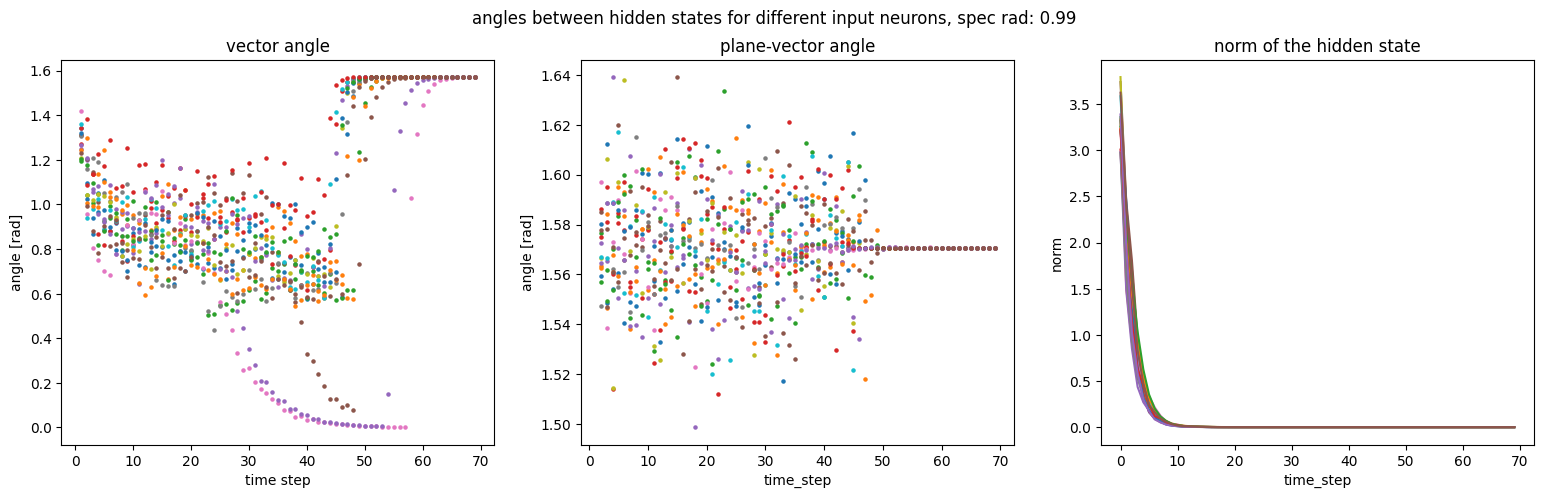

In [11]:
time_steps = 70
#[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
spectral_radius = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5, 6, 7, 8]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=1
fixed_whh=True
fixed_wih=False

from sf_workingdir_lilly.dmlab.custom_esn_analysis import compute_angle_between_hidden_states, compute_angle_plane_hidden_state


#neuron_norms_for_srs = np.zeros((len(spectral_radius), Hippo_n_feature,time_steps))
x_vals = np.arange(1,70)
x_vals_plane = np.arange(2,70)

for sr_i, sr in enumerate(spectral_radius):
    # create a (input_index, time_steps) matrix for each spectral radius - values in the matrix are the norms at this input index at that tiem - and create a plot where the norms are plotted against the time
    #neuron_norms = np.zeros((Hippo_n_feature,time_steps))
    fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(19,5))
    for i in range(Hippo_n_feature):
        hs = get_hidden_states_iso_feat(time_steps, sr, Hippo_n_feature, Hippo_R, Hippo_L, trial, fixed_whh, fixed_wih, input_idx=i)  # size: (time_steps, hidden_size)
        angles = compute_angle_between_hidden_states(hs, time_steps)
        angles_plane = compute_angle_plane_hidden_state(hs, time_steps)

        norms = hs.norm(dim=1)
        
        #neuron_norms[i,:] = norms
        #neuron_norms_for_srs[sr_i,i,:] = norms
        
        ax1.scatter(x_vals, angles, label=f'{i}', s=5)
        ax2.scatter(x_vals_plane, angles_plane, label=f'{i}', s=5)
        ax3.plot(norms, label=f'{i}')
    
        fig.suptitle(f'angles between hidden states for different input neurons, spec rad: {sr}')
        ax1.set_title('vector angle')
        ax2.set_title('plane-vector angle')
        ax3.set_title('norm of the hidden state')
        ax1.set_xlabel('time step')
        ax2.set_xlabel('time_step')
        ax3.set_xlabel('time_step')
        ax1.set_ylabel('angle [rad]')
        ax2.set_ylabel('angle [rad]')
        ax3.set_ylabel('norm')